In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib

plt.style.use('ggplot')
sns.set_palette("husl")

In [184]:
df = pd.read_csv('Nazarov.csv', index_col=0)

In [185]:
print(f"количество писем: {df.shape[0]}")
print(f"количество признаков (слов): {df.shape[1] - 1}")

количество писем: 5172
количество признаков (слов): 3000


In [186]:
y = df['Prediction'].values
X = df.drop(columns=['Prediction']).values

In [187]:
print("\nРАСПРЕДЕЛЕНИЕ КЛАССОВ:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = "📧 РАБОТА" if cls == 1 else "🏠 ЛИЧНОЕ"
    print(f"{label} (класс {cls}): {cnt} писем ({cnt/len(y)*100:.1f}%)")


РАСПРЕДЕЛЕНИЕ КЛАССОВ:
🏠 ЛИЧНОЕ (класс 0): 3672 писем (71.0%)
📧 РАБОТА (класс 1): 1500 писем (29.0%)


In [188]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [189]:
print(f"обучающая: {X_train.shape[0]} писем")
print(f"тестовая: {X_test.shape[0]} писем")
print(f"признаков: {X_train.shape[1]}")

обучающая: 4137 писем
тестовая: 1035 писем
признаков: 3000


In [190]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [191]:
print(f"среднее обучающей выборки: {X_train_scaled.mean():.6f}")
print(f"стд обучающей выборки: {X_train_scaled.std():.6f}")

среднее обучающей выборки: 0.000000
стд обучающей выборки: 1.000000


In [192]:
word_columns = df.drop(columns=['Prediction']).columns

work_mask = y_train == 1
personal_mask = y_train == 0

work_means = X_train[work_mask].mean(axis=0)
personal_means = X_train[personal_mask].mean(axis=0)

difference = work_means - personal_means

top_work_idx = np.argsort(difference)[-10:][::-1]
top_work_words = [(word_columns[i], difference[i]) for i in top_work_idx]

top_personal_idx = np.argsort(difference)[:10]
top_personal_words = [(word_columns[i], abs(difference[i])) for i in top_personal_idx]

C:\Users\rnaza\miniconda3\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\rnaza\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


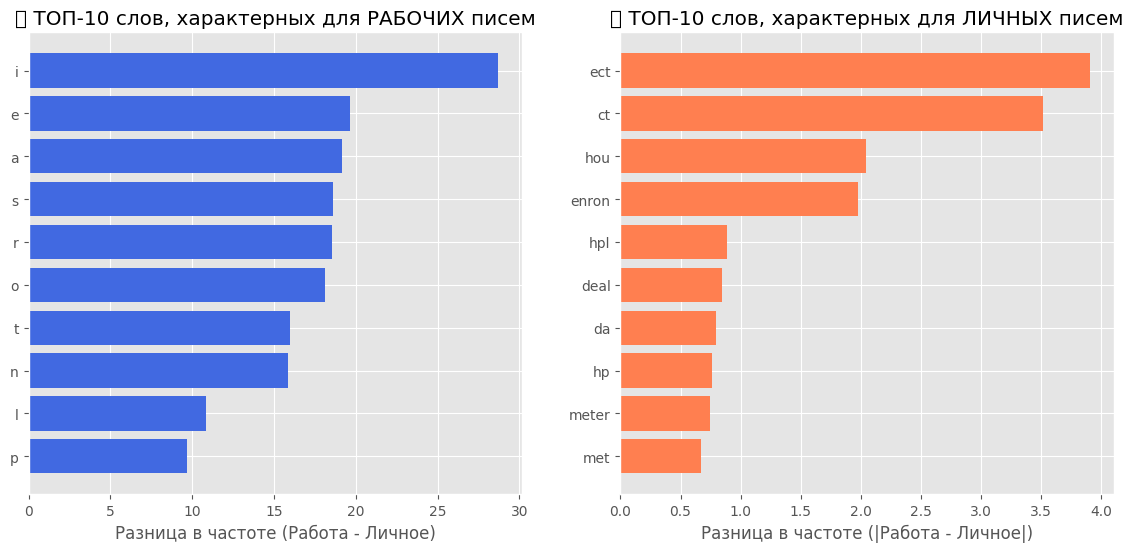

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words_w, values_w = zip(*top_work_words)
axes[0].barh(range(len(words_w)), values_w, color='royalblue')
axes[0].set_yticks(range(len(words_w)))
axes[0].set_yticklabels(words_w)
axes[0].set_xlabel('Разница в частоте (Работа - Личное)')
axes[0].set_title('🔝 ТОП-10 слов, характерных для РАБОЧИХ писем')
axes[0].invert_yaxis()

words_p, values_p = zip(*top_personal_words)
axes[1].barh(range(len(words_p)), values_p, color='coral')
axes[1].set_yticks(range(len(words_p)))
axes[1].set_yticklabels(words_p)
axes[1].set_xlabel('Разница в частоте (|Работа - Личное|)')
axes[1].set_title('🔝 ТОП-10 слов, характерных для ЛИЧНЫХ писем')
axes[1].invert_yaxis()

In [194]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [195]:
print("рабочие письма чаще содержат слова:", ', '.join(words_w[:5]))
print("личные письма чаще содержат слова:", ', '.join(words_p[:5]))

рабочие письма чаще содержат слова: i, e, a, s, r
личные письма чаще содержат слова: ect, ct, hou, enron, hpl


In [196]:
model = Sequential([
    # входной слой + первый скрытый слой
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    # второй скрытый слой
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # третий скрытый слой
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # четвертый скрытый слой
    Dense(32, activation='relu'),

    # выходной слой (1 нейрон для бинарной классификации)
    Dense(1, activation='sigmoid')
])

C:\Users\rnaza\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [197]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [198]:
print("🏗️ АРХИТЕКТУРА НЕЙРОННОЙ СЕТИ:")
print("=" * 50)
model.summary()
print("=" * 50)
print(f"Всего параметров: {model.count_params():,}")

🏗️ АРХИТЕКТУРА НЕЙРОННОЙ СЕТИ:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,313 (3.10 MB)

 Trainable params: 812,417 (3.10 MB)

 Non-trainable params: 896 (3.50 KB)

Всего параметров: 813,313


In [199]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [200]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

In [201]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7860 - loss: 0.4359 - precision_2: 0.6149 - recall_2: 0.7406 - val_accuracy: 0.9481 - val_loss: 0.1551 - val_precision_2: 0.8450 - val_recall_2: 0.9864 - learning_rate: 0.0010
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9486 - loss: 0.1477 - precision_2: 0.9057 - recall_2: 0.9224 - val_accuracy: 0.9589 - val_loss: 0.1008 - val_precision_2: 0.8816 - val_recall_2: 0.9774 - learning_rate: 0.0010
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9725 - loss: 0.0805 - precision_2: 0.9577 - recall_2: 0.9489 - val_accuracy: 0.9734 - val_loss: 0.0768 - val_precision_2: 0.9270 - val_recall_2: 0.9774 - learning_rate: 0.0010
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9758 - loss: 0.0670 - precision_2: 0.9658 - recall_2: 0.9520 - val_accuracy: 0.9601 - val_loss: 0.1017 - val_precision_2: 0.8790 - val_recall_2: 0.9864 - learning_rate: 0.0010
Epoch 5/100
104/104 ━━━━━━━

In [202]:
print(f"лучшая точность: {max(history.history['val_accuracy']):.4f}")

лучшая точность: 0.9746


C:\Users\rnaza\AppData\Local\Temp\ipykernel_14920\2131557517.py:21: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rnaza\AppData\Local\Temp\ipykernel_14920\2131557517.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rnaza\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rnaza\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


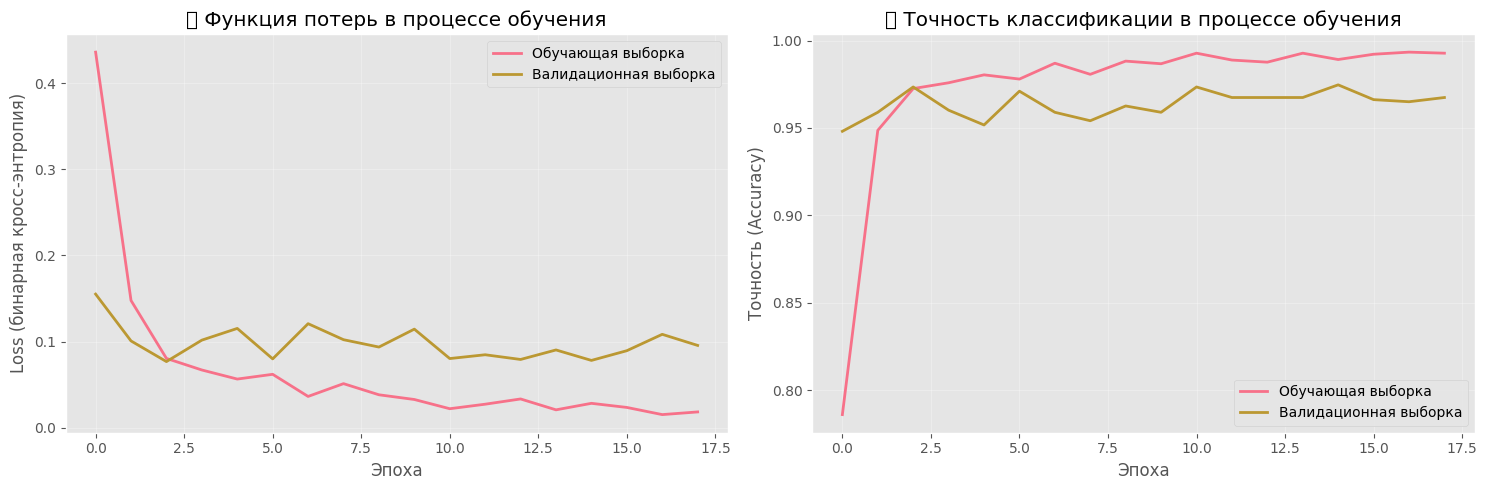

In [203]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# график потерь (loss)
axes[0].plot(history.history['loss'], label='Обучающая выборка', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Валидационная выборка', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss (бинарная кросс-энтропия)')
axes[0].set_title('📉 Функция потерь в процессе обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# график точности
axes[1].plot(history.history['accuracy'], label='Обучающая выборка', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Валидационная выборка', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность (Accuracy)')
axes[1].set_title('📈 Точность классификации в процессе обучения')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [204]:
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_accuracy = accuracy_score(y_test, y_pred)
print("=" * 50)
print("📊 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 50)
print(f"🎯 Точность (Accuracy): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n" + "=" * 50)
print("ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print("=" * 50)
print(classification_report(
    y_test, y_pred,
    target_names=['🏠 ЛИЧНОЕ (0)', '📧 РАБОТА (1)']
))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
📊 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
🎯 Точность (Accuracy): 0.9739 (97.39%)

ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:
              precision    recall  f1-score   support

🏠 ЛИЧНОЕ (0)       0.99      0.97      0.98       735
📧 РАБОТА (1)       0.93      0.98      0.96       300

    accuracy                           0.97      1035
   macro avg       0.96      0.98      0.97      1035
weighted avg       0.97      0.97      0.97      1035



In [205]:
def classify_email(email_word_counts, scaler, model, word_columns):
    """
    Функция для сортировки нового письма

    Параметры:
    - email_word_counts: список или массив с частотами слов
    - scaler: обученный StandardScaler
    - model: обученная нейросеть
    - word_columns: список всех слов (колонок)

    Возвращает:
    - "📧 РАБОТА" или "🏠 ЛИЧНОЕ" и уверенность модели
    """
    # Преобразуем в numpy массив
    email_vector = np.array(email_word_counts).reshape(1, -1)

    # Нормализуем
    email_scaled = scaler.transform(email_vector)

    # Предсказываем
    prediction_proba = model.predict(email_scaled, verbose=0)[0][0]

    if prediction_proba > 0.5:
        label = "📧 РАБОТА"
        confidence = prediction_proba
    else:
        label = "🏠 ЛИЧНОЕ"
        confidence = 1 - prediction_proba

    return label, confidence

In [206]:
print("🧪 ТЕСТОВЫЙ ПРИМЕР СОРТИРОВКИ ПИСЬМА:")
print("=" * 50)

# Берем первое письмо из тестовой выборки
test_email = X_test[0]
real_class = "РАБОТА" if y_test[0] == 1 else "ЛИЧНОЕ"
predicted_class, confidence = classify_email(test_email, scaler, model, word_columns)

print(f"Реальный класс письма: {real_class}")
print(f"Нейросеть определила как: {predicted_class}")
print(f"Уверенность модели: {confidence:.2%}")

🧪 ТЕСТОВЫЙ ПРИМЕР СОРТИРОВКИ ПИСЬМА:
Реальный класс письма: ЛИЧНОЕ
Нейросеть определила как: 🏠 ЛИЧНОЕ
Уверенность модели: 99.92%


In [207]:
top_word_indices = np.argsort(test_email)[-5:][::-1]
print("\n📝 Топ-5 слов в этом письме:")
for idx in top_word_indices:
    if test_email[idx] > 0:
        print(f"  • {word_columns[idx]}: {int(test_email[idx])} раз(а)")


📝 Топ-5 слов в этом письме:
  • e: 40 раз(а)
  • t: 30 раз(а)
  • o: 30 раз(а)
  • a: 28 раз(а)
  • n: 27 раз(а)


In [208]:
model.save('email_classifier_nazarov.keras')
joblib.dump(scaler, 'email_scaler_nazarov.pkl')
with open('word_columns_nazarov.txt', 'w', encoding='utf-8') as f:
    for word in word_columns:
        f.write(word + '\n')